### Install Dependencies

In [1]:
### !pip install diffusers transformers accelerate torch torchvision safetensors matplotlib pillow -q

### Importing Necessary Libraries

In [2]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt
from datetime import datetime
import os

### Setup Device (Auto GPU/CPU Detection)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {device.upper()}")


✅ Using device: CPU


### Load Model (Lightweight & Stable)

In [5]:
model_id = "runwayml/stable-diffusion-v1-5"

print("📦 Loading model... please wait (1–2 minutes on first run)...")

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)
# Enable optimized mode for low VRAM GPUs
if device == "cuda":
    pipe.enable_model_cpu_offload()
else:
    pipe.to("cpu")

print("✅ Model loaded successfully!")


📦 Loading model... please wait (1–2 minutes on first run)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


✅ Model loaded successfully!


### Create Output Directory

In [6]:
output_dir = "generated_sketches"
os.makedirs(output_dir, exist_ok=True)


### Get User Inputs

In [8]:
print("\n🧍‍♂️ Enter the details of the person you want to generate as a sketch:\n")

def ask(prompt_text, default=""):
    resp = input(prompt_text).strip()
    return resp if resp != "" else default

# Gender selection
gender = ask("Gender (Male / Female): ").capitalize()
if gender.lower() not in ("male", "female"):
    gender = "Male" if gender == "" else gender  # fallback, but keep what's provided

# Age details
age_group = ask("Age (Child / Teen / Young Adult / 25-year-old / Middle-aged / Elderly): ", "young adult")

# Basic features
hair = ask("Hair Type & Style (e.g., long curly hair, short straight hair): ", "medium length hair")
face_shape = ask("Face Shape (e.g., oval, round, square, heart-shaped): ", "oval")
eyes = ask("Eye Type (e.g., large eyes, small eyes, sharp eyes): ", "normal eyes")
nose = ask("Nose Type (e.g., pointed, broad, small): ", "straight nose")
expression = ask("Facial Expression (e.g., smiling, neutral, angry): ", "neutral expression")

# New: eyebrows (applies to all)
eyebrows = ask("Eyebrow style (e.g., thick brows, thin arched brows, straight brows): ", "natural eyebrows")

# New: ears (applies to all)
ears = ask("Ear type/visibility (e.g., small ears, visible ears, covered by hair, attached earlobes): ", "visible ears")

# ---------- CONDITIONAL FEATURES FOR MALE ----------
beard = ""
mustache = ""
if gender.lower() == "male":
    has_beard = ask("Does he have a beard? (yes/no): ", "no").lower()
    if has_beard == "yes":
        beard = ask("Describe the beard (e.g., stubble, trimmed beard, long beard): ", "short stubble")

    has_mustache = ask("Does he have a mustache? (yes/no): ", "no").lower()
    if has_mustache == "yes":
        mustache = ask("Describe the mustache (e.g., thick mustache, small mustache): ", "small mustache")

# ---------- CONDITIONAL FEATURES FOR FEMALE ----------
earrings = ""
if gender.lower() == "female":
    has_earrings = ask("Does she have earrings? (yes/no): ", "no").lower()
    if has_earrings == "yes":
        # ask a more specific earring type (requested)
        earrings = ask("Describe the earrings (e.g., studs, long danglers, hoop earrings, pearl studs): ", "studs")

# ---------- EXTRAS (Works even if 'No') ----------
extras = ask("Any other accessories (e.g., glasses, hat, necklace). If none, type 'no': ", "no").lower()

# Clean extras (ignore useless input)
if extrasn in ["no", "none", "nothing", "", "nil"]:
    extras = ""



🧍‍♂️ Enter the details of the person you want to generate as a sketch:



Gender (Male / Female):  male
Age (Child / Teen / Young Adult / 25-year-old / Middle-aged / Elderly):  47
Hair Type & Style (e.g., long curly hair, short straight hair):  short silky
Face Shape (e.g., oval, round, square, heart-shaped):  round square
Eye Type (e.g., large eyes, small eyes, sharp eyes):  small
Nose Type (e.g., pointed, broad, small):  broad
Facial Expression (e.g., smiling, neutral, angry):  neutral
Eyebrow style (e.g., thick brows, thin arched brows, straight brows):  thin
Ear type/visibility (e.g., small ears, visible ears, covered by hair, attached earlobes):  visible
Does he have a beard? (yes/no):  no
Does he have a mustache? (yes/no):  yes
Describe the mustache (e.g., thick mustache, small mustache):  thick
Any other accessories (e.g., glasses, hat, necklace). If none, type 'no':  no


NameError: name 'extrasn' is not defined

### BUILD THE FINAL FEATURES LIST

In [10]:
features = [
    hair,
    f"{face_shape} face",
    eyes,
    f"{nose} nose",
    f"{expression} expression",
    eyebrows,
    ears
]

if beard:
    features.append(beard)
if mustache:
    features.append(mustache)
if earrings:
    features.append(earrings)
if extras:
    features.append(extras)

# join features into a readable phrase (avoid extra commas if empty entries)
all_features = ", ".join([f for f in features if f and f.strip()])

### Create Text Prompt

In [11]:
prompt = (
    f"pencil sketch portrait of a {age_group.lower()} {gender.lower()} "
    f"with {all_features}. realistic pencil drawing, artistic line art, "
    f"detailed shading, monochrome on white background."
)

print("\n🎨 Generated Prompt:\n", prompt)


🎨 Generated Prompt:
 pencil sketch portrait of a 47 male with short silky, round square face, small, broad nose, neutral expression, thin, visible, thick, no. realistic pencil drawing, artistic line art, detailed shading, monochrome on white background.


### Generate Image

In [12]:
print("\n🖌️ Generating your AI sketch... please wait (around 30 seconds)...")

image = pipe(
    prompt,
    num_inference_steps=25,       # Faster inference
    guidance_scale=8.5            # Stronger prompt adherence
).images[0]


🖌️ Generating your AI sketch... please wait (around 30 seconds)...


  0%|          | 0/25 [00:00<?, ?it/s]

### Display the Generated Image

C:\Users\admin\anaconda3\envs\project\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


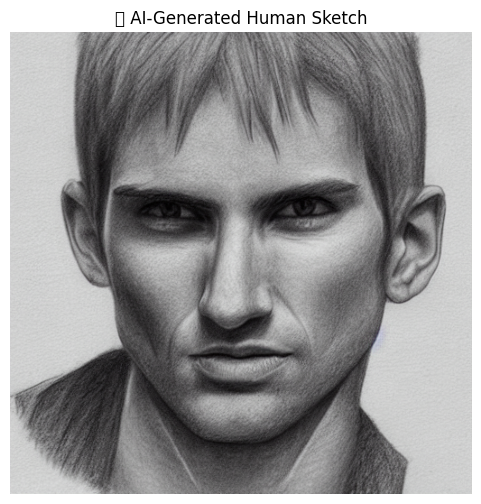

In [13]:
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("🧠 AI-Generated Human Sketch")
plt.show()

### Save the Image with Timestamp

In [14]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"sketch_{timestamp}.png"
save_path = os.path.join(output_dir, filename)
image.save(save_path)

print(f"\n✅ Sketch generated and saved successfully at: {save_path}")


✅ Sketch generated and saved successfully at: generated_sketches\sketch_20260109_125342.png
